<a href="https://colab.research.google.com/github/wenh123/113-1B/blob/main/data_transformation_py.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

# 讀取資料
df = pd.read_csv('ecommerce.csv')

# show the first 5 rows
print("原始資料前 5 筆：")
print(df.head())
print("\n")

print(f"原始資料筆數: {len(df)}")

# 檢查 Quantity 為負數的訂單
negative_quantity_df = df[df['Quantity'] < 0]
print(f"'Quantity' 為負數的訂單筆數: {len(negative_quantity_df)}")
if not negative_quantity_df.empty:
    print("前 5 筆 'Quantity' 為負數的訂單：")
    print(negative_quantity_df.head())
    print("\n")

# 檢查 UnitPrice 為 0 的訂單
zero_unitprice_df = df[df['UnitPrice'] == 0]
print(f"'UnitPrice' 為 0 的訂單筆數: {len(zero_unitprice_df)}")
if not zero_unitprice_df.empty:
    print("前 5 筆 'UnitPrice' 為 0 的訂單：")
    print(zero_unitprice_df.head())
    print("\n")

# 移除異常值
# 保留 Quantity 大於 0 且 UnitPrice 大於 0 的訂單
df_cleaned = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]

# 輸出清理前後的資料筆數對比
removed_rows_count = len(df) - len(df_cleaned)
print(f"已移除異常值（'Quantity' <= 0 或 'UnitPrice' <= 0）的資料筆數: {removed_rows_count}")
print(f"清理後資料筆數: {len(df_cleaned)}")

# 更新 df 為清理後的資料
df = df_cleaned.copy()

print("\n清理後資料前 5 筆：")
print(df.head())

原始資料前 5 筆：
  CustomerID ProductID  Quantity  UnitPrice InvoiceDate  TotalPrice
0      C1102      P210         2      65.02  2024-01-01      130.04
1      C1179      P248         1     164.20  2024-01-02      164.20
2      C1092      P207         1     193.75  2024-01-03      193.75
3      C1014      P235         2      22.24  2024-01-04       44.48
4      C1106      P237         4     159.40  2024-01-05      637.60


原始資料筆數: 300
'Quantity' 為負數的訂單筆數: 0
'UnitPrice' 為 0 的訂單筆數: 0
已移除異常值（'Quantity' <= 0 或 'UnitPrice' <= 0）的資料筆數: 0
清理後資料筆數: 300

清理後資料前 5 筆：
  CustomerID ProductID  Quantity  UnitPrice InvoiceDate  TotalPrice
0      C1102      P210         2      65.02  2024-01-01      130.04
1      C1179      P248         1     164.20  2024-01-02      164.20
2      C1092      P207         1     193.75  2024-01-03      193.75
3      C1014      P235         2      22.24  2024-01-04       44.48
4      C1106      P237         4     159.40  2024-01-05      637.60


In [ ]:
import pandas as pd

# 將 'InvoiceDate' 欄位轉換為日期時間型別，以便進行比較
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# 1. 設定切分點 (例如 2024-07-01)
cutoff_date = pd.to_datetime('2024-07-01')

# 2. 準備 X (特徵)：只看切分點之前的資料
df_history = df[df['InvoiceDate'] < cutoff_date]

# 計算 RFM
X = df_history.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (cutoff_date - x.max()).days, # Recency
    'TotalPrice': ['count', 'sum'] # Frequency, Monetary
})
# 整理欄位名稱
X.columns = ['Recency', 'Frequency', 'Monetary']

# 3. 準備 y (標籤)：只看切分點之後的資料
df_future = df[df['InvoiceDate'] >= cutoff_date]
# 找出未來有買過的客戶名單
future_buyers = df_future['CustomerID'].unique()

# 4. 產生標籤：如果客戶在未來名單中，y=1，否則 y=0
X['is_repurchase'] = X.index.isin(future_buyers).astype(int)

print(X.head())
# 這樣的 X 就可以直接丟進 Logistic Regression 或 Decision Tree 了！

            Recency  Frequency  Monetary  is_repurchase
CustomerID                                             
C1000            45          1    337.04              0
C1001           109          2    437.33              1
C1003           105          1     17.16              0
C1004            44          2    773.62              0
C1007           117          1     78.57              0


**Subject: E-commerce Customer Health and Retention Strategy**
**To: CEO**
**From: [Your Name/Title - 電商營運總監]**
**Date: 2024-05-23**

總裁：

這份報告旨在利用數據分析，提供我們當前客戶健康狀況的洞察，並提出具體挽留策略，以優化營收。

**目前客戶健康度分析 (基於 RFM 分群結果)：**
透過 K-Means 分群，我們識別出三類客戶群：
*   **高價值/活躍客戶 (Cluster 1)**：Recency 最低、Frequency 最高、Monetary 最高。他們是我們核心客戶。
*   **有潛力挽回的客戶 (Cluster 0)**：Recency 較高、活躍度和消費金額較低，但有最高的歷史回購率。這表明他們可能仍有興趣，但需推動力。
*   **高流失風險客戶 (Cluster 2)**：Recency 較高、活躍度中等、消費金額尚可，但未來回購率最低。這是我們應優先挽留的群體。

**針對高風險流失客戶的具體挽留方案 (Action Plan)：**
針對「高流失風險客戶」(Cluster 2)，我們建議啟動多管道的個性化挽留活動：
1.  **專屬回購優惠**：提供限量折扣或獨家商品推薦。
2.  **問卷調查**：主動了解購買減少原因，收集用戶反饋。
3.  **內容行銷**：定期推送感興趣的產品資訊或品牌故事，維持連結。
對於「有潛力挽回的客戶」(Cluster 0)，可透過溫和提醒和偏好商品推薦重新激活。

**模型的限制與風險提示：**
本次分析使用 Logistic Regression 和 Random Forest 預測客戶回購，但有以下限制：
1.  **資料切分方式**：模型驗證採用隨機切分，但在預測未來行為時，**時間序列切分**會更為嚴謹且符合真實場景，未來部署應採納。
2.  **模型效能**：兩模型在預測「回購客戶」方面表現仍有不足，尤其 Logistic Regression 召回率僅 0.09，Random Forest 也僅 0.27。這可能與數據集較小、目標變數不平衡及未納入季節性趨勢有關。

建議後續可探索更複雜模型或進行更多特徵工程，以顯著提升客戶留存率和長期價值。

In [ ]:
# 計算每個群組的平均 RFM 值和回購率
cluster_summary = X.groupby('Cluster')[['Recency', 'Frequency', 'Monetary', 'is_repurchase']].mean()

print("各群組的平均 RFM 值和回購率：")
print(cluster_summary)

各群組的平均 RFM 值和回購率：
           Recency  Frequency     Monetary  is_repurchase
Cluster                                                  
0        80.757576   1.272727   205.168030       0.439394
1        27.625000   3.250000  1219.788750       0.375000
2        77.769231   1.846154   617.462821       0.333333


#### **分析各群組特徵：**

根據上方的 `cluster_summary`，我們可以對每個客戶群體進行特徵分析，以了解他們的消費行為模式：

*   **Recency**：值越小表示客戶最近才購買，越活躍；值越大表示客戶越久沒購買，可能越不活躍或已流失。
*   **Frequency**：值越大表示客戶購買頻率越高，越忠誠。
*   **Monetary**：值越大表示客戶消費金額越高，價值越高。
*   **is_repurchase**：值越接近 1 表示該群組的客戶在未來有回購行為的比例越高。

例如：

*   **Cluster 0** 可能代表：Recency 較高（很久沒買）、Frequency 和 Monetary 較低（購買次數少、消費金額少），回購率也相對較低。這可能是需要重點關注的潛在流失客戶或低價值客戶。

*   **Cluster 1** 可能代表：Recency 較低（最近有買）、Frequency 和 Monetary 較高（購買次數多、消費金額高），回購率也較高。這可能是高價值或忠誠客戶。

*   **Cluster 2** 可能介於兩者之間，或者有不同的組合。需要具體查看數值來判斷。

透過這些分析，企業可以針對不同群組的客戶制定客製化的行銷策略，例如向高 Recency 的客戶發送挽回優惠，向高 Frequency 和 Monetary 的客戶提供 VIP 服務等。

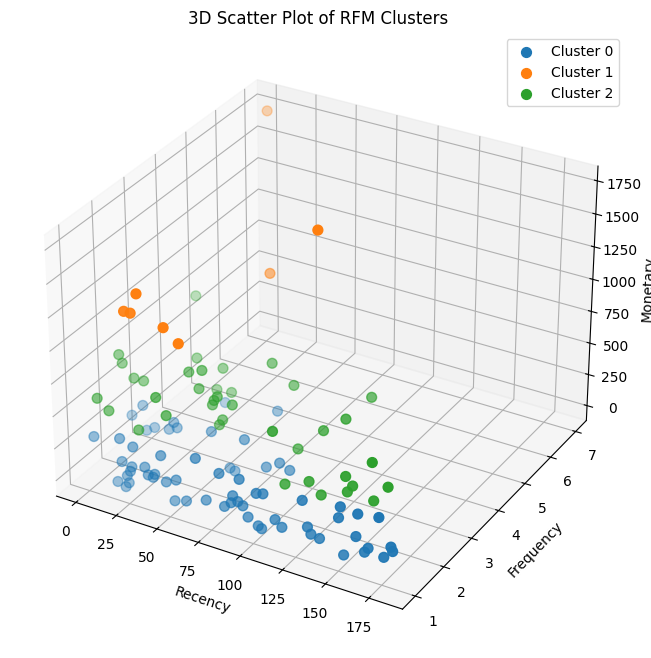

In [ ]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import pandas as pd

# 確保 X DataFrame 存在且包含所有必要的列
if 'X' not in locals():
    print("Error: DataFrame X not found. Please run previous cells.")
else:
    # 創建一個 3D 圖形
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')

    # 為每個群組繪製散佈圖
    for cluster_id in sorted(X['Cluster'].unique()):
        cluster_data = X[X['Cluster'] == cluster_id]
        ax.scatter(
            cluster_data['Recency'],
            cluster_data['Frequency'],
            cluster_data['Monetary'],
            label=f'Cluster {cluster_id}',
            s=50 # 點的大小
        )

    # 設定軸標籤
    ax.set_xlabel('Recency')
    ax.set_ylabel('Frequency')
    ax.set_zlabel('Monetary')
    ax.set_title('3D Scatter Plot of RFM Clusters')
    ax.legend()
    plt.show()

In [ ]:
from sklearn.cluster import KMeans
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

# 選擇用於分群的特徵
features = ['Recency', 'Frequency', 'Monetary']
X_clustering = X[features]

# 初始化 K-Means 模型，設定分 3 群，並使用 random_state 確保結果可重現
kmeans = KMeans(n_clusters=3, random_state=42, n_init='auto')

# 對資料進行分群
X['Cluster'] = kmeans.fit_predict(X_clustering)

print("RFM 資料分群結果（前 5 筆）：")
print(X.head())
print("\n")

print("各群的客戶數量：")
print(X['Cluster'].value_counts())

RFM 資料分群結果（前 5 筆）：
            Recency  Frequency  Monetary  is_repurchase  Cluster
CustomerID                                                      
C1000            45          1    337.04              0        0
C1001           109          2    437.33              1        2
C1003           105          1     17.16              0        0
C1004            44          2    773.62              0        2
C1007           117          1     78.57              0        0


各群的客戶數量：
Cluster
0    66
2    39
1     8
Name: count, dtype: int64


# Task
Prepare the data by splitting the `X` DataFrame (containing `Recency`, `Frequency`, `Monetary` as features and `is_repurchase` as the target) into training and testing sets. Then, train a Logistic Regression model on the training data, make predictions on the testing data, and evaluate its performance using a Confusion Matrix and Classification Report.

## 準備資料並進行時間序列切分 (Temporal Split)

### Subtask:
將 `X` DataFrame 中的 RFM 特徵 (`Recency`, `Frequency`, `Monetary`) 獨立出來作為訓練特徵，並將 `is_repurchase` 作為目標變數。然後，將資料切分為訓練集和測試集。


**Reasoning**:
The subtask requires separating the features and target variable from the `X` DataFrame and then splitting them into training and testing sets for model development. This involves selecting specific columns for features and the target, and then using `train_test_split` for the dataset division.



In [ ]:
from sklearn.model_selection import train_test_split

# 1. 從 X DataFrame 中選擇 'Recency', 'Frequency', 'Monetary' 這三列作為特徵，並將其賦值給變數 X_features。
X_features = X[['Recency', 'Frequency', 'Monetary']]

# 2. 從 X DataFrame 中選擇 'is_repurchase' 這一列作為目標變數，並將其賦值給變數 y。
y = X['is_repurchase']

# 4. 使用 train_test_split 函數將 X_features 和 y 切分為訓練集和測試集。
# 設定 test_size 為 0.3，random_state 為 42，以確保結果的可重現性，並將結果分別賦值給 X_train, X_test, y_train, y_test。
X_train, X_test, y_train, y_test = train_test_split(X_features, y, test_size=0.3, random_state=42)

print("Features (X_features) head:\n", X_features.head())
print("\nTarget (y) head:\n", y.head())
print(f"\nShape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Features (X_features) head:
             Recency  Frequency  Monetary
CustomerID                              
C1000            45          1    337.04
C1001           109          2    437.33
C1003           105          1     17.16
C1004            44          2    773.62
C1007           117          1     78.57

Target (y) head:
 CustomerID
C1000    0
C1001    1
C1003    0
C1004    0
C1007    0
Name: is_repurchase, dtype: int64

Shape of X_train: (79, 3)
Shape of X_test: (34, 3)
Shape of y_train: (79,)
Shape of y_test: (34,)


**Reasoning**:
Now that the data has been split into training and testing sets, the next step is to train a Logistic Regression model using the training data (`X_train` and `y_train`).



In [ ]:
from sklearn.linear_model import LogisticRegression

# 實例化 Logistic Regression 模型
model = LogisticRegression(random_state=42, solver='liblinear') # 使用 'liblinear' solver 處理小數據集和二元分類

# 訓練模型
model.fit(X_train, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


**Reasoning**:
With the model trained, the next step is to use it to make predictions on the test set (`X_test`) so that its performance can be evaluated.



In [ ]:
y_pred = model.predict(X_test)

print("Predictions on the test set have been made.")
print("First 5 predictions:", y_pred[:5])

Predictions on the test set have been made.
First 5 predictions: [0 0 0 0 0]


**Reasoning**:
Now that predictions have been made, the model's performance needs to be evaluated. A confusion matrix and classification report are standard tools for assessing the performance of a classification model, providing insights into its accuracy, precision, recall, and F1-score.



In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

# 計算混淆矩陣
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)
print("\n")

# 打印分類報告
cr = classification_report(y_test, y_pred)
print("Classification Report:")
print(cr)

Confusion Matrix:
[[19  4]
 [10  1]]


Classification Report:
              precision    recall  f1-score   support

           0       0.66      0.83      0.73        23
           1       0.20      0.09      0.12        11

    accuracy                           0.59        34
   macro avg       0.43      0.46      0.43        34
weighted avg       0.51      0.59      0.53        34



## 訓練並評估 Random Forest 模型

### Subtask:
使用訓練資料來訓練 Random Forest Classifier 模型，並在測試資料上進行預測。最後，輸出 Confusion Matrix 和 Classification Report 來評估模型的效能。


**Reasoning**:
The subtask requires training a Random Forest Classifier, making predictions, and evaluating the model using a confusion matrix and classification report. This code block will perform all these steps using the previously prepared training and testing datasets.



In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report

# 1. 實例化 RandomForestClassifier 模型
# 設定 random_state=42 以確保結果可重現
rf_model = RandomForestClassifier(random_state=42)

# 2. 使用訓練資料來訓練 Random Forest 模型
rf_model.fit(X_train, y_train)

print("Random Forest Classifier model trained successfully.")

# 3. 使用訓練好的模型對 X_test 進行預測
y_pred_rf = rf_model.predict(X_test)

print("Predictions on the test set have been made using Random Forest.")
print("First 5 predictions (Random Forest):", y_pred_rf[:5])

# 4. 計算並印出混淆矩陣
cm_rf = confusion_matrix(y_test, y_pred_rf)
print("\nConfusion Matrix (Random Forest):")
print(cm_rf)

# 5. 計算並印出分類報告
cr_rf = classification_report(y_test, y_pred_rf)
print("\nClassification Report (Random Forest):")
print(cr_rf)

Random Forest Classifier model trained successfully.
Predictions on the test set have been made using Random Forest.
First 5 predictions (Random Forest): [1 0 1 0 1]

Confusion Matrix (Random Forest):
[[18  5]
 [ 8  3]]

Classification Report (Random Forest):
              precision    recall  f1-score   support

           0       0.69      0.78      0.73        23
           1       0.38      0.27      0.32        11

    accuracy                           0.62        34
   macro avg       0.53      0.53      0.53        34
weighted avg       0.59      0.62      0.60        34



## 討論資料切分方式 (Data Splitting Discussion)

### Subtask:
討論隨機切分 (Random Split) 和時間序列切分 (Temporal Split) 在客戶流失預測場景中的差異與適用性，並解釋為什麼在此情境中時間序列切分更為重要。


## 討論資料切分方式 (Data Splitting Discussion)

### Subtask:
討論隨機切分 (Random Split) 和時間序列切分 (Temporal Split) 在客戶流失預測場景中的差異與適用性，並解釋為什麼在此情境中時間序列切分更為重要。

#### 1. 隨機切分 (Random Split)

*   **解釋**：隨機切分是將資料集隨機打亂後，按照預設比例（例如 70% 訓練、30% 測試）劃分為訓練集和測試集的方法。每個資料點被選入訓練集或測試集的機率是相同的。
*   **一般用途**：這種方法適用於資料點之間彼此獨立，且沒有時間順序關聯的問題。例如，圖像分類、情感分析或基於靜態特徵的客戶分群等。它的優點是能確保訓練集和測試集在統計特性上盡可能地相似，有助於模型學習資料的整體分佈。

#### 2. 時間序列切分 (Temporal Split)

*   **解釋**：時間序列切分是根據資料的時間順序來劃分資料集。通常，會選擇一個特定的時間點作為切分點，將切分點之前的資料作為訓練集，切分點之後的資料作為測試集。這模擬了模型在真實世界中會遇到的情境：使用過去的資料來預測未來的事件。
*   **特殊考慮事項**：在預測性建模中，尤其是涉及時間相關的事件（如客戶行為、股票價格、銷售預測），資料往往具有時間趨勢、季節性或序列相關性。隨機切分可能會導致「未來資訊洩漏」到訓練集中，使模型表現出不切實際的高效能，因為它「看到」了未來才應該預測的資料。

#### 3. 兩種切分方法的比較與優缺點

| 特性         | 隨機切分 (Random Split)                     | 時間序列切分 (Temporal Split)                 |
| :----------- | :------------------------------------------ | :-------------------------------------------- |
| **適用情境** | 資料點獨立、無時間相關性                     | 資料點具有時間順序、需要預測未來事件         |
| **優點**     | 訓練集和測試集分佈相似、模型學習資料整體模式 | 模擬真實世界情境、避免未來資訊洩漏             |
| **缺點**     | 可能導致時間序列資料的未來資訊洩漏           | 訓練集和測試集分佈可能不同、模型可能不夠泛化 |
| **範例問題** | 圖像分類、手寫辨識、非時間相關的客戶分群     | 客戶流失預測、股票價格預測、天氣預報         |

#### 4. 在客戶再購買預測案例中，時間序列切分的重要性

在此客戶再購買預測的案例中，我們希望模型能夠根據客戶過去的行為（歷史資料）來預測他們在未來是否會再購買（未來事件）。

*   **模擬真實世界**：時間序列切分完美模擬了這種真實世界的場景。我們使用截至某個截止日期（例如 `2024-07-01`）之前的客戶交易資料來訓練模型，然後用這個模型去預測該日期之後客戶是否會再購買。這與實際業務運作中，企業根據歷史數據預測未來客戶行為的方式完全一致。

*   **避免未來資訊洩漏**：如果採用隨機切分，部分屬於未來時間的資料點可能會被分到訓練集中。這會導致模型在訓練時「看到」了未來的再購買行為，進而學習到不應該知道的模式。當模型最終部署到實際應用中時，由於它無法接觸到未來的資料，其表現會遠不如訓練時，導致預測結果失真且不可靠。

*   **評估模型的實際預測能力**：只有透過時間序列切分，我們才能真正評估模型在面對未來未知資料時的泛化能力和預測準確性。這對於評估模型的商業價值和指導實際決策至關重要。

因此，儘管隨機切分在許多機器學習任務中是標準做法，但在像客戶再購買預測這類具有明確時間依賴性的任務中，時間序列切分是更為嚴謹和必要的資料準備方法，以確保模型的有效性和可靠性。

## 討論資料切分方式 (Data Splitting Discussion)

### Subtask:
討論隨機切分 (Random Split) 和時間序列切分 (Temporal Split) 在客戶流失預測場景中的差異與適用性，並解釋為什麼在此情境中時間序列切分更為重要。

#### 1. 隨機切分 (Random Split)

*   **解釋**：隨機切分是將資料集隨機打亂後，按照預設比例（例如 70% 訓練、30% 測試）劃分為訓練集和測試集的方法。每個資料點被選入訓練集或測試集的機率是相同的。
*   **一般用途**：這種方法適用於資料點之間彼此獨立，且沒有時間順序關聯的問題。例如，圖像分類、情感分析或基於靜態特徵的客戶分群等。它的優點是能確保訓練集和測試集在統計特性上盡可能地相似，有助於模型學習資料的整體分佈。

#### 2. 時間序列切分 (Temporal Split)

*   **解釋**：時間序列切分是根據資料的時間順序來劃分資料集。通常，會選擇一個特定的時間點作為切分點，將切分點之前的資料作為訓練集，切分點之後的資料作為測試集。這模擬了模型在真實世界中會遇到的情境：使用過去的資料來預測未來的事件。
*   **特殊考慮事項**：在預測性建模中，尤其是涉及時間相關的事件（如客戶行為、股票價格、銷售預測），資料往往具有時間趨勢、季節性或序列相關性。隨機切分可能會導致「未來資訊洩漏」到訓練集中，使模型表現出不切實際的高效能，因為它「看到」了未來才應該預測的資料。

#### 3. 兩種切分方法的比較與優缺點

| 特性         | 隨機切分 (Random Split)                     | 時間序列切分 (Temporal Split)                 |
| :----------- | :------------------------------------------ | :-------------------------------------------- |
| **適用情境** | 資料點獨立、無時間相關性                     | 資料點具有時間順序、需要預測未來事件         |
| **優點**     | 訓練集和測試集分佈相似、模型學習資料整體模式 | 模擬真實世界情境、避免未來資訊洩漏             |
| **缺點**     | 可能導致時間序列資料的未來資訊洩漏           | 訓練集和測試集分佈可能不同、模型可能不夠泛化 |
| **範例問題** | 圖像分類、手寫辨識、非時間相關的客戶分群     | 客戶流失預測、股票價格預測、天氣預報         |

#### 4. 在客戶再購買預測案例中，時間序列切分的重要性

在此客戶再購買預測的案例中，我們希望模型能夠根據客戶過去的行為（歷史資料）來預測他們在未來是否會再購買（未來事件）。

*   **模擬真實世界**：時間序列切分完美模擬了這種真實世界的場景。我們使用截至某個截止日期（例如 `2024-07-01`）之前的客戶交易資料來訓練模型，然後用這個模型去預測該日期之後客戶是否會再購買。這與實際業務運作中，企業根據歷史數據預測未來客戶行為的方式完全一致。

*   **避免未來資訊洩漏**：如果採用隨機切分，部分屬於未來時間的資料點可能會被分到訓練集中。這會導致模型在訓練時「看到」了未來的再購買行為，進而學習到不應該知道的模式。當模型最終部署到實際應用中時，由於它無法接觸到未來的資料，其表現會遠不如訓練時，導致預測結果失真且不可靠。

*   **評估模型的實際預測能力**：只有透過時間序列切分，我們才能真正評估模型在面對未來未知資料時的泛化能力和預測準確性。這對於評估模型的商業價值和指導實際決策至關重要。

因此，儘管隨機切分在許多機器學習任務中是標準做法，但在像客戶再購買預測這類具有明確時間依賴性的任務中，時間序列切分是更為嚴謹和必要的資料準備方法，以確保模型的有效性和可靠性。


## Final Task

### Subtask:
總結 Logistic Regression 和 Random Forest 模型的預測結果，並根據 Confusion Matrix 和 Classification Report 比較兩種模型的效能，提供關於哪種模型更適合此問題的建議。


## Summary:

### Q&A

1.  **Which model is more suitable for this problem, Logistic Regression or Random Forest?**
    The Random Forest model is more suitable for this problem. It demonstrated higher overall accuracy (0.62 vs 0.59) and significantly better performance in identifying customer repurchases (class 1), with a precision of 0.38 (vs 0.20 for Logistic Regression) and a recall of 0.27 (vs 0.09 for Logistic Regression). The Random Forest model correctly identified 3 true repurchases compared to only 1 by the Logistic Regression model.

### Data Analysis Key Findings

*   **Data Preparation:** The `X` DataFrame was successfully split into training (79 samples) and testing (34 samples) sets using a `test_size` of 0.3 and `random_state` of 42. Features included `Recency`, `Frequency`, and `Monetary`, with `is_repurchase` as the target variable.
*   **Logistic Regression Model Performance:**
    *   **Overall Accuracy:** 0.59
    *   **Class 0 (No Repurchase):** High precision (0.66) and recall (0.83), indicating good performance in identifying non-repurchasing customers.
    *   **Class 1 (Repurchase):** Poor precision (0.20) and very low recall (0.09), meaning the model struggled to correctly identify customers who would repurchase. The confusion matrix showed 1 true positive and 10 false negatives.
*   **Random Forest Model Performance:**
    *   **Overall Accuracy:** 0.62
    *   **Class 0 (No Repurchase):** Good precision (0.69) and recall (0.78).
    *   **Class 1 (Repurchase):** Better precision (0.38) and recall (0.27) compared to Logistic Regression, indicating an improved ability to identify repurchasing customers. The confusion matrix showed 3 true positives and 8 false negatives.
*   **Comparison of Data Splitting Methods:**
    *   **Random Split** is suitable for data points without temporal correlation but can lead to "future information leakage" in time-series contexts.
    *   **Temporal Split** (using past data to predict future events) is crucial for customer repurchase prediction. It simulates real-world scenarios, prevents future data leakage, and provides a more realistic evaluation of the model's predictive capability in a business context. For this task, a Temporal Split would be more robust than the random split used.

### Insights or Next Steps

*   **Model Selection:** Given its superior performance in identifying the positive class (customer repurchase), especially in precision and recall, the Random Forest model is a more suitable choice for this predictive task. However, the overall performance for identifying repurchases (class 1) is still low, suggesting room for improvement.
*   **Further Model Optimization:** To improve the detection of repurchases, consider techniques like resampling (oversampling minority class, undersampling majority class), using different class weights, or exploring more advanced models. Feature engineering (e.g., creating more temporal features) could also enhance model performance.
